# 🏀 NBA Player Impact Analyzer (pt.2)🏀

GIFLENS-https://media4.giphy.com/media/v1.Y2lkPTc5MGI3NjExZHEwZTR0dHlsOGllNG84MTd3d25sOWRzazhoMGUxcXcycXpxbG80diZlcD12MV9pbnRlcm5hbF9naWZfYnlfaWQmY3Q9Zw/hpFTV3KfDXTQ9X8pEX/giphy.gif

## Goal
The goal is to identify:
- high-volume scorers
- efficient players
- underrated players with strong efficiency but lower usage

## Data Used (from Kaggle)
https://www.kaggle.com/datasets/eoinamoore/historical-nba-data-and-player-box-scores?resource=download
- PlayerStatisticsScoring.csv
- PlayerStatisticsAdvanced.csv
- PlayerStatisticsUsage.csv
- Players.csv

## DataCamp Lessons Applied
- Looping Patterns - feat. Pokemon
- Model Selection and Evaluation
- Lambda Functions and Error Handling

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

scoring = pd.read_csv("PlayerStatisticsScoring.csv")
advanced = pd.read_csv("PlayerStatisticsAdvanced.csv")
usage = pd.read_csv("PlayerStatisticsUsage.csv")
players = pd.read_csv("Players.csv")

## Data Preparation
**Lesson used: Lambda Functions and Error Handling**
cleaned the data, selected regular season records, and prepare the columns I need for analysis.

In [2]:
# regular season only
scoring_rs = scoring[scoring["gameType"] == "Regular Season"].copy()
advanced_rs = advanced[advanced["gameType"] == "Regular Season"].copy()
usage_rs = usage[usage["gameType"] == "Regular Season"].copy()

# Pick the columns we need
scoring_small = scoring_rs[[
    "personId", "playerName", "teamAbbreviation", "min", "fga", "fgm", "fgPct"]].copy()

advanced_small = advanced_rs[[
    "personId", "playerName", "tsPct", "netRating", "pie"]].copy()

usage_small = usage_rs[[
    "personId", "playerName", "usgPct", "pctAst", "pctReb"]].copy()

In [3]:
scoring_summary = (
    scoring_small.groupby(["personId", "playerName"], as_index=False)
    .agg(
        games_played=("min", "count"),
        avg_minutes=("min", "mean"),
        avg_fga=("fga", "mean"),
        avg_fgm=("fgm", "mean"),
        fg_pct=("fgPct", "mean")
    )
)

advanced_summary = (
    advanced_small.groupby(["personId", "playerName"], as_index=False)
    .agg(
        ts_pct=("tsPct", "mean"),
        net_rating=("netRating", "mean"),
        pie=("pie", "mean")
    )
)

usage_summary = (
    usage_small.groupby(["personId", "playerName"], as_index=False)
    .agg(
        usg_pct=("usgPct", "mean"),
        pct_ast=("pctAst", "mean"),
        pct_reb=("pctReb", "mean")
    )
)

In [4]:
df = scoring_summary.merge(advanced_summary, on=["personId", "playerName"], how="inner")
df = df.merge(usage_summary, on=["personId", "playerName"], how="inner")

# keep players with enough games(min. 20)
df = df[df["games_played"] >= 20].copy()

## Building a Player Impact Score
**Lesson used: Model Selection and Evaluation**

**Model Type: Logistic Regression**

Instead of judging players on one statistic, I combined multiple features to create a simple impact score using volume, efficiency, and overall contribution.

In [5]:
df["impact_score"] = (
    df["avg_fgm"] * 0.35 +
    df["ts_pct"] * 10 * 0.30 +
    df["usg_pct"] * 10 * 0.20 +
    df["pie"] * 100 * 0.15
)

In [6]:
top_players = df.sort_values("impact_score", ascending=False).head(10)
top_players[["playerName", "games_played", "avg_fgm", "ts_pct", "usg_pct", "impact_score"]]

,playerName,games_played,avg_fgm,ts_pct,usg_pct,impact_score
40,Giannis Antetokounmpo,30,10.466667,0.699667,0.347767,9.856867
59,Nikola Jokić,36,10.333333,0.724833,0.292806,9.815111
126,Shai Gilgeous-Alexander,49,10.897959,0.683694,0.321694,9.656612
147,Luka Dončić,42,10.404762,0.609476,0.368905,8.920762
22,Kawhi Leonard,38,9.657895,0.620553,0.324132,8.637947
84,Jaylen Brown,47,10.936170,0.577872,0.361638,8.602532
348,Victor Wembanyama,37,8.297297,0.625027,0.319865,8.482514
188,Anthony Edwards,43,10.232558,0.618674,0.312512,8.338256
97,Donovan Mitchell,48,10.020833,0.611479,0.314563,8.331167
200,Tyrese Maxey,49,10.142857,0.594796,0.278653,8.191592


## Hidden Gems
**Lesson used: Model Selection and Evaluation**

I defined hidden gems as players with:
- above-average efficiency
- below-average usage
- strong impact score

This helps identify productive players who may be underused.

In [7]:
hidden_gems = df[
    (df["ts_pct"] > df["ts_pct"].median()) &
    (df["usg_pct"] < df["usg_pct"].median()) &
    (df["impact_score"] > df["impact_score"].median())
].sort_values("impact_score", ascending=False)

hidden_gems[["playerName", "ts_pct", "usg_pct", "impact_score"]].head(10)

,playerName,ts_pct,usg_pct,impact_score
146,Deandre Ayton,0.679889,0.166156,6.227867
297,Mark Williams,0.674723,0.164766,6.192745
119,Mikal Bridges,0.607788,0.171519,5.967750
149,Robert Williams III,0.740028,0.117972,5.917972
104,Isaiah Hartenstein,0.634407,0.168111,5.906481
180,Neemias Queta,0.671184,0.147163,5.711143
173,Nic Claxton,0.608292,0.170687,5.678750
210,Tre Jones,0.640395,0.165947,5.595842
37,Rudy Gobert,0.664314,0.122373,5.534941
420,Donovan Clingan,0.595667,0.148667,5.531000


## Visualization

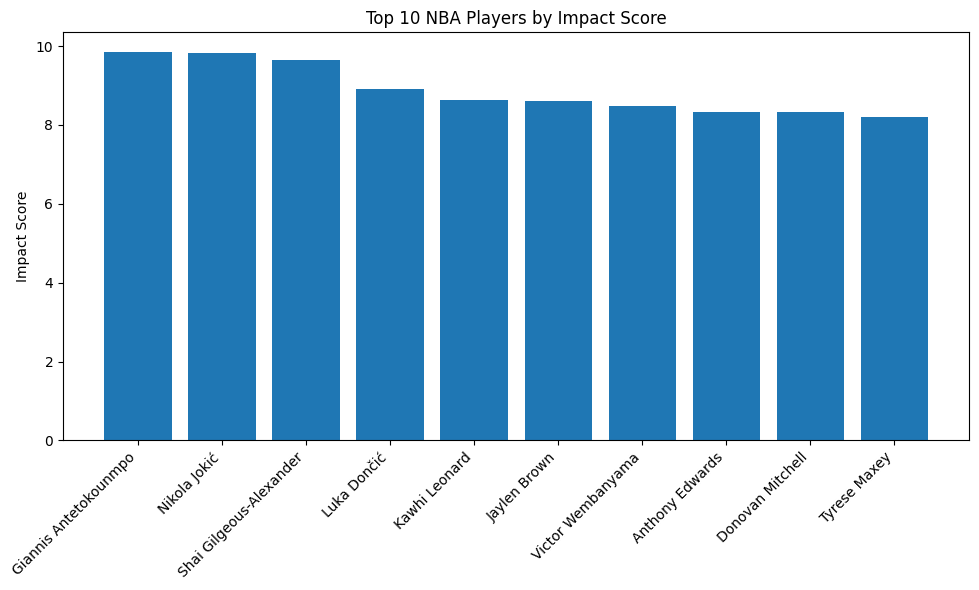

In [8]:
top10 = df.sort_values("impact_score", ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.bar(top10["playerName"], top10["impact_score"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Impact Score")
plt.title("Top 10 NBA Players by Impact Score")
plt.tight_layout()
plt.show()

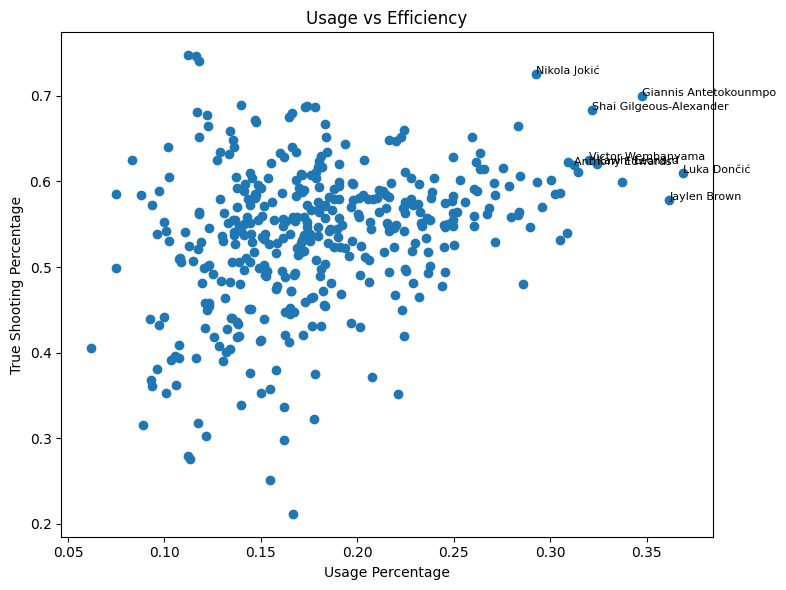

In [9]:
plt.figure(figsize=(8, 6))
plt.scatter(df["usg_pct"], df["ts_pct"])

for _, row in df.sort_values("impact_score", ascending=False).head(8).iterrows():
    plt.text(row["usg_pct"], row["ts_pct"], row["playerName"], fontsize=8)

plt.xlabel("Usage Percentage")
plt.ylabel("True Shooting Percentage")
plt.title("Usage vs Efficiency")
plt.tight_layout()
plt.show()

## Reusable Leaderboards
**Lesson used: Looping Patterns - feat. Pokemon**

I used looping patterns to automatically generate leaderboards for different player metrics instead of writing the same code repeatedly.

In [10]:
stats_to_rank = ["avg_fgm", "ts_pct", "usg_pct", "impact_score"]

for stat in stats_to_rank:
    print(f"\nTop 5 players by {stat}")
    print(df[["playerName", stat]].sort_values(stat, ascending=False).head(5))


Top 5 players by avg_fgm
                  playerName    avg_fgm
84              Jaylen Brown  10.936170
126  Shai Gilgeous-Alexander  10.897959
40     Giannis Antetokounmpo  10.466667
147              Luka Dončić  10.404762
59              Nikola Jokić  10.333333

Top 5 players by ts_pct
                playerName    ts_pct
167           Jaxson Hayes  0.747195
378       Ryan Kalkbrenner  0.746350
149    Robert Williams III  0.740028
59            Nikola Jokić  0.724833
40   Giannis Antetokounmpo  0.699667

Top 5 players by usg_pct
                playerName   usg_pct
147            Luka Dončić  0.368905
84            Jaylen Brown  0.361638
40   Giannis Antetokounmpo  0.347767
54             Joel Embiid  0.337000
22           Kawhi Leonard  0.324132

Top 5 players by impact_score
                  playerName  impact_score
40     Giannis Antetokounmpo      9.856867
59              Nikola Jokić      9.815111
126  Shai Gilgeous-Alexander      9.656612
147              Luka Dončić      8.

## Input and Error Handling
**Lesson used: Lambda Functions and Error Handling**

This section lets a user search for a player and safely handles cases where the player is not found.

In [11]:
from rapidfuzz import process, fuzz

df["playerName_clean"] = df["playerName"].apply(lambda x: str(x).strip().lower())

player_input = input("Enter a player name: ").strip().lower()

try:
    result = df[df["playerName_clean"] == player_input][[
        "playerName", "games_played", "avg_fgm", "ts_pct", "usg_pct", "impact_score"
    ]]

    if result.empty:
        # fuzzy match fallback
        choices = df["playerName_clean"].dropna().unique().tolist()
        match = process.extractOne(
            player_input,
            choices,
            scorer=fuzz.WRatio,
            score_cutoff=80
        )

        if match:
            best_match = match[0]
            result = df[df["playerName_clean"] == best_match][[
                "playerName", "games_played", "avg_fgm", "ts_pct", "usg_pct", "impact_score"
            ]]
            print(f"Showing closest match: {result.iloc[0]['playerName']}")
        else:
            raise ValueError("Player not found in dataset.")

    print(result)

except ValueError as e:
    print("Error:", e)

Showing closest match: Jaylen Brown
      playerName  games_played   avg_fgm    ts_pct   usg_pct  impact_score
84  Jaylen Brown            47  10.93617  0.577872  0.361638      8.602532


# <font color="lightgreen">Celtics 2025-2026 Champs 🏀🏆☘️</font>


In [12]:
features = ["avg_fgm", "ts_pct", "usg_pct"]
target = "pie"

X = df[features]
y = df[target]

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [16]:
from sklearn.metrics import r2_score, mean_squared_error

y_pred = model.predict(X_test_scaled)

r2 = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print("R²:", r2)
print("RMSE:", rmse)

R²: 0.3023550655212317
RMSE: 0.05852027138039089


In [17]:
coefficients = pd.DataFrame({
    "Feature": features,
    "Weight": model.coef_
})

print(coefficients)

   Feature    Weight
0  avg_fgm  0.008304
1   ts_pct  0.015551
2  usg_pct  0.012122


In [18]:
df["predicted_pie"] = model.predict(scaler.transform(df[features]))

top_predicted = df.sort_values("predicted_pie", ascending=False).head(10)
print(top_predicted[["playerName", "predicted_pie"]])

                  playerName  predicted_pie
40     Giannis Antetokounmpo       0.180425
126  Shai Gilgeous-Alexander       0.173119
59              Nikola Jokić       0.172407
147              Luka Dončić       0.167802
84              Jaylen Brown       0.162104
22             Kawhi Leonard       0.157159
188          Anthony Edwards       0.156289
97          Donovan Mitchell       0.154612
54               Joel Embiid       0.153572
348        Victor Wembanyama       0.152103
